In [1]:
import numpy as np
import scipy
import scipy.special as sp
import matplotlib.pyplot as plt
import h5py
from localized_2d import WfnParams, Wavefunction, HamiltParams, Hamilt

In [2]:
%%capture
%run vgh_2d_analysis.ipynb

TODO: 

- compare the energies from the tunneling matrix with the energies that we have

In [3]:
def get_e_loc_for_coupling(dir,Mx,My,tx,ty,B,V_0_arr):
    e_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_arr_tun = np.zeros(len(V_0_arr), dtype=complex)
    
    e_T_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_V_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_B_arr = np.zeros(len(V_0_arr), dtype=complex)

    Tx_arr = np.zeros(len(V_0_arr), dtype=complex)
    Ty_arr = np.zeros(len(V_0_arr), dtype=complex)

    for i in range(len(V_0_arr)):
        V_0 = V_0_arr[i]
        file_path = dir+'data_B_'+str(B)+'_V0_'+str(V_0)+'_tx_'+str(tx)+'_ty_'+str(ty)+'_'+str(int(Mx))+'x'+str(int(My))+'.h5'

        with h5py.File(file_path, 'r') as f:
            phi_data = f["wfn"][...]
            Mx = f["Mx"][...]
            My = f["My"][...]
            n = f["n"][...]
            B = f["B"][...]
            tx = f["tx"][...]
            ty = f["ty"][...]
            V_0 = f["V0"][...]
            e_tun = f["e_tun"][...]
            v_tun = f["v_tun"][...]

        wfnpar = WfnParams(Mx, My, n)
        Mx, My, n, x, k2 = wfnpar.read()

        wfn = Wavefunction(wfnpar, array=phi_data)

        hamiltpar = HamiltParams(B, tx, ty, V_0)

        H = Hamilt(wfnpar, hamiltpar)
        energy_tot, energy_rot, energy_ele, energy_int = H.calculate_energy(wfn)
        Tx, Ty = H.calc_Tx_Ty(wfn)
        
        e_arr[i] = energy_tot
        e_T_arr[i] = energy_ele
        e_B_arr[i] = np.sum(energy_rot)
        e_V_arr[i] = np.sum(energy_int)

        e_arr_tun[i] = e_tun[0]

        Tx_arr[i] = Tx
        Ty_arr[i] = Ty
        
    return e_arr, e_arr_tun, e_T_arr, e_B_arr, e_V_arr, Tx_arr, Ty_arr

def get_state_e_loc_data(dir,Mx,My,tx_arr,ty_arr,B,V_0_arr):
    e_arr = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)
    e_tun_arr = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)

    e_T_arr = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)
    e_B_arr = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)
    e_V_arr = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)
    
    Tx_arr = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)
    Ty_arr = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)
    for i in range(len(tx_arr)):
        tx = tx_arr[i]
        ty = ty_arr[i]

        e_flp, e_tun, e_flp_T, e_flp_B, e_flp_V, Tx_flp, Ty_flp = get_e_loc_for_coupling(dir=dir,Mx=Mx,My=My,tx=tx,ty=ty,B=B,V_0_arr=V_0_arr)

        e_arr[i] = e_flp
        e_tun_arr[i] = e_tun 
        
        e_T_arr[i] = e_flp_T
        e_B_arr[i] = e_flp_B
        e_V_arr[i] = e_flp_V


        Tx_arr[i] = Tx_flp
        Ty_arr[i] = Ty_flp

    return e_arr, e_T_arr, e_B_arr, e_V_arr, Tx_arr, Ty_arr

def get_wfn_loc_for_coupling(dir,Mx,My,tx,ty,B,V_0):
    e_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_arr_tun = np.zeros(len(V_0_arr), dtype=complex)
    
    e_T_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_V_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_B_arr = np.zeros(len(V_0_arr), dtype=complex)

    Tx_arr = np.zeros(len(V_0_arr), dtype=complex)
    Ty_arr = np.zeros(len(V_0_arr), dtype=complex)

    file_path = dir+'data_B_'+str(B)+'_V0_'+str(V_0)+'_tx_'+str(tx)+'_ty_'+str(ty)+'_'+str(int(Mx))+'x'+str(int(My))+'.h5'

    with h5py.File(file_path, 'r') as f:
        phi_data = f["wfn"][...]
        Mx = f["Mx"][...]
        My = f["My"][...]
        n = f["n"][...]
        B = f["B"][...]
        tx = f["tx"][...]
        ty = f["ty"][...]
        V_0 = f["V0"][...]
        e_tun = f["e_tun"][...]
        v_tun = f["v_tun"][...]

    wfnpar = WfnParams(Mx, My, n)
    Mx, My, n, x, k2 = wfnpar.read()

    wfn = Wavefunction(wfnpar, array=phi_data)

    hamiltpar = HamiltParams(B, tx, ty, V_0)

    H = Hamilt(wfnpar, hamiltpar)
    energy_tot, energy_rot, energy_ele, energy_int = H.calculate_energy(wfn)
    Tx, Ty = H.calc_Tx_Ty(wfn)

    return x, wfn.rotwfn, wfn.elewfn, energy_tot, energy_ele, energy_rot, energy_int, Tx, Ty

def Px_Py_rotwfn(x,Mx,My,phi_data):
    P_arr = np.zeros((My,Mx), dtype=complex)
    Px_arr = np.zeros((My,Mx), dtype=complex)
    Py_arr = np.zeros((My,Mx), dtype=complex)
    for i in range(My):
        for j in range(Mx):
            Px = np.sum(np.cos(x)*np.abs(phi_data[i,j,:])**2) 
            Py = np.sum(np.sin(x)*np.abs(phi_data[i,j,:])**2)

            P_arr[i,j] = (Px**2 + Py**2)**0.5
            Px_arr[i,j] = Px
            Py_arr[i,j] = Py

    return P_arr, Px_arr, Py_arr

In [181]:
def get_eff_mass_for_coupling(dir,Mx,My,tx,ty,B,V_0):
    e_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_arr_tun = np.zeros(len(V_0_arr), dtype=complex)
    
    e_T_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_V_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_B_arr = np.zeros(len(V_0_arr), dtype=complex)

    Tx_arr = np.zeros(len(V_0_arr), dtype=complex)
    Ty_arr = np.zeros(len(V_0_arr), dtype=complex)

    file_path = dir+'data_B_'+str(B)+'_V0_'+str(V_0)+'_tx_'+str(tx)+'_ty_'+str(ty)+'_'+str(int(Mx))+'x'+str(int(My))+'.h5'

    with h5py.File(file_path, 'r') as f:
        phi_data = f["wfn"][...]
        Mx = f["Mx"][...]
        My = f["My"][...]
        n = f["n"][...]
        B = f["B"][...]
        tx = f["tx"][...]
        ty = f["ty"][...]
        V_0 = f["V0"][...]
        e_tun = f["e_tun"][...]
        v_tun = f["v_tun"][...]
        
    wfnpar = WfnParams(Mx, My, n)
    Mx, My, n, x, k2 = wfnpar.read()

    wfn = Wavefunction(wfnpar, array=phi_data)

    hamiltpar = HamiltParams(B, tx, ty, V_0)

    H = Hamilt(wfnpar, hamiltpar)
    energy_tot, energy_rot, energy_ele, energy_int = H.calculate_energy(wfn)
    Tx, Ty = H.calc_Tx_Ty(wfn)

    H, B = H.tunneling_hamiltonian(wfn)

    '''
    Here starts computation of matrix elements
    '''
    get_matrix = lambda fun_: np.array([[fun_(m, n) for n in range(My)] for m in range(Mx)])
    elewfn_shift_mat = get_matrix(wfn.elewfn_shift)
    rotwfn_shift_mat = get_matrix(wfn.rotwfn_shift)

    Oe = np.einsum('mnij,ij->mnij', np.conj(elewfn_shift_mat), wfn.elewfn)
    OE = np.sum(Oe, axis=(2, 3))

    Or = np.einsum('mnkij,kij->mnij', np.conj(rotwfn_shift_mat), wfn.rotwfn)
    OR = np.prod(Or, axis=(2, 3))

    He = (-tx * (np.roll(OE, 1, axis=0) + np.roll(OE, -1, axis=0)) \
        -ty * (np.roll(OE, 1, axis=1) + np.roll(OE, -1, axis=1))) * OR

    return He


'''
Get State Properties for a phase diagram scan in the delta_t-V_0 plane
'''
V_0_arr = np.array([0.0,0.2,0.4,0.6,1.0,1.2,1.6,2.0])
#V_0_arr = np.array([0.6])

Mx = 20
My = 20
tx = 0.5
ty = 0.5
B = 1e-2

mx = np.zeros(len(V_0_arr))
my = np.zeros(len(V_0_arr))
dire = 'data_localized/'
for i in range(len(V_0_arr)):
    He = get_eff_mass_for_coupling(dir=dir,Mx=Mx,My=My,tx=tx,ty=ty,B=B,V_0=V_0_arr[i])

    indx = np.repeat(np.arange(Mx)[::-1]+1, (Mx,)).reshape(My,Mx)
    multiplicities = indx*indx.T
    
    kx = np.arange(Mx)
    kx[kx > Mx/2] = -(kx[kx > Mx/2]%(Mx/2))[::-1]

    ky = np.arange(My)
    ky[ky > My/2] = -(ky[ky > My/2]%(My/2))[::-1]

    mx2Hem = np.einsum('ij,i->ij', -He*multiplicities, kx**2).real
    my2Hem = np.einsum('ij,j->ij', -He*multiplicities, ky**2).real
    
    mx[i] = (Mx*My)/np.sum(mx2Hem)
    my[i] = (Mx*My)/np.sum(my2Hem)

    print(V_0_arr[i], mx[i], my[i])

0.0 0.00014214641417131463 0.00014214641417131463
0.2 0.00014214650150439506 0.0001421465015043951
0.4 255.11876418898922 255.1187641889889
0.6 3780.0042092955728 3780.0042092955414
1.0 46441.030872651885 46441.03087265275
1.2 75080.7421039695 75080.74210396955
1.6 106458.69393786525 106458.69393786554
2.0 105276.99173828008 105276.99173828134


In [179]:
print(kx)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20 -19 -18 -17 -16 -15 -14 -13 -12 -11 -10  -9  -8  -7  -6  -5
  -4  -3  -2  -1]


In [176]:
test = np.einsum('ij,i->ij', 2*multiplicities, kx**2).real

print(test.shape)
print(np.sum(test)/(Mx*My))
print(Mx*My/np.sum(test))

(40, 40)
109470.0
9.134922809902257e-06


In [164]:
multiplicities = np.zeros((4,4))
for m in range(4):
    multiplicities += (4-m)*np.eye(4, k = -m) + (3-m)*np.eye(4, k = m+1)

print(multiplicities*multiplicities)

indx = np.repeat(np.arange(4)[::-1]+1, (4,)).reshape(4,4)
print(indx*indx.T)

[[16.  9.  4.  1.]
 [ 9. 16.  9.  4.]
 [ 4.  9. 16.  9.]
 [ 1.  4.  9. 16.]]
[[16 12  8  4]
 [12  9  6  3]
 [ 8  6  4  2]
 [ 4  3  2  1]]


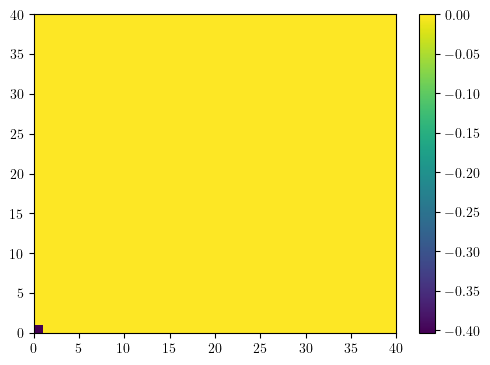

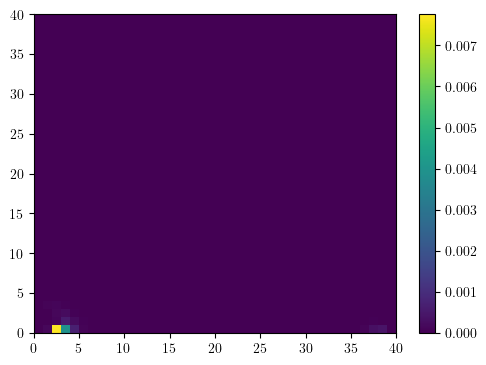

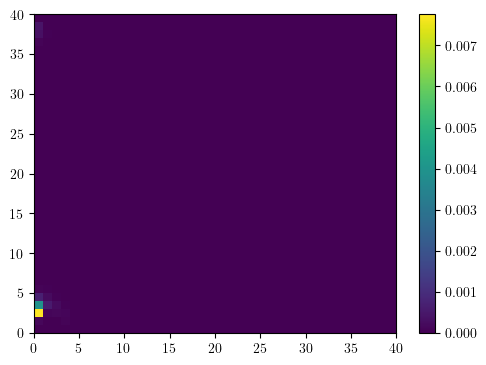

In [178]:
pc = plt.pcolormesh(He.real)
plt.colorbar(pc)
plt.show()

pc = plt.pcolormesh(my2Hem)
plt.colorbar(pc)
plt.show()

pc = plt.pcolormesh(mx2Hem)
plt.colorbar(pc)
plt.show()

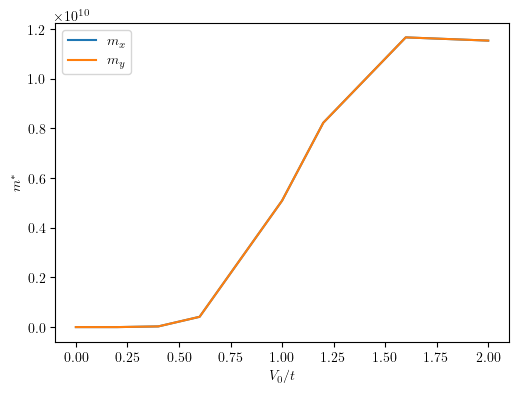

In [177]:
plt.plot(V_0_arr, mx/mx[0], label=r'$m_x$')
plt.plot(V_0_arr, my/my[0], label=r'$m_y$')

plt.xlabel(r'$V_0/t$')
plt.ylabel(r'$m^*$')
plt.legend()

(400, 400) (400, 400) (20, 20) (20, 20)
(1+0j)
(-914.8100756439801-4.228112929409798e-17j)
(7.856806652059726e-05+0j) (1+0j)
(18.40111514090008+0j)
(2684.619858194909+0j)


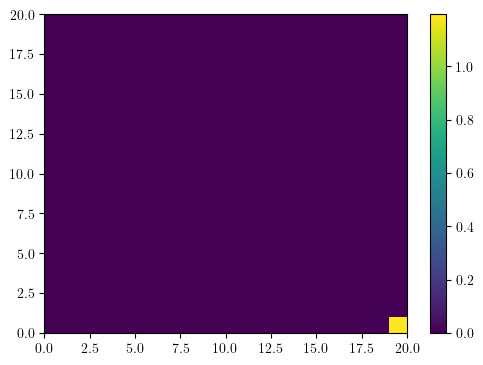

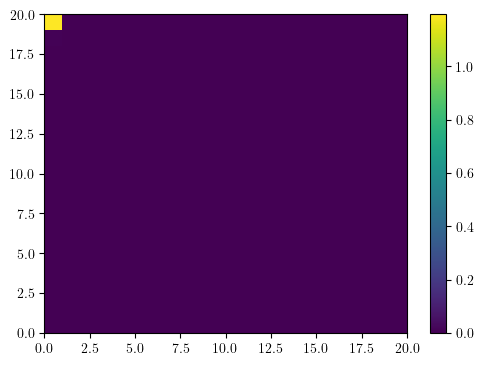

In [76]:
print(H.shape, Bm.shape, OE.shape, OR.shape)

Hem_test = my2Hem.copy()
Hem_test[0,0] = 0
print(OE[0,0])
print(np.sum(H))
print(np.min(OE), np.max(OE))
print(np.sum(OE))
print(1/np.sum(OE)/2.024291534028121e-05)
#pc = plt.pcolormesh(Hem_test.real)
pc = plt.pcolormesh(Hem_test.real)
plt.colorbar(pc)
plt.show()

pc = plt.pcolormesh(mx2Hem.real)
plt.colorbar(pc)
plt.show()

# Energy Analysis

In [5]:
'''
Get State Properties for a phase diagram scan in the delta_t-V_0 plane
'''
V_0_arr = np.array([0.4])

Mx = 20
My = 20
tx = 0.5
ty = 0.5
B = 1e-2

dir = 'data_localized/'
e, e_tun, e_T, e_B, e_V, Tx, Ty = get_e_loc_for_coupling(dir=dir,Mx=Mx,My=My,tx=tx,ty=ty,B=B,V_0_arr=V_0_arr)

print('E     =', e, '\nE_tun =', e_tun, '\nE_T   =', e_T, '\nE_B   =', e_B, '\nE_V   =', e_V, '\nTx    =', Tx, '\nTy    =', Ty)

E     = [-2.2674772-1.13085789e-19j] 
E_tun = [-2.26918503-1.04877562e-19j] 
E_T   = [-1.4946766+0.j] 
E_B   = [0.11912462-1.13085789e-19j] 
E_V   = [-0.89192521+0.j] 
Tx    = [1.4946766+0.j] 
Ty    = [1.4946766+0.j]


In [79]:
'''
Get State Properties for a phase diagram scan in the delta_t-V_0 plane
'''
V_0_arr = np.array([0.0,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.2,1.4,1.6,1.8,2.0,2.2,2.4,2.6,2.8,3.0,3.2,3.4])

Mx = 20
My = 20
tx_arr = np.array([0.5,0.6,0.7,0.8,0.9,1.0])
ty_arr = np.array([0.5,0.4,0.3,0.2,0.1,0.0])
B = 1e-2

qx=0.0
qy=0.0

dir='data_localized/'
e_arr, e_T_arr, e_B_arr, e_V_arr, Tx_arr, Ty_arr = get_state_e_loc_data(dir=dir,Mx=Mx,My=My,tx_arr=tx_arr,ty_arr=ty_arr,B=B,V_0_arr=V_0_arr)

tx = 0.5  ty = 0.5


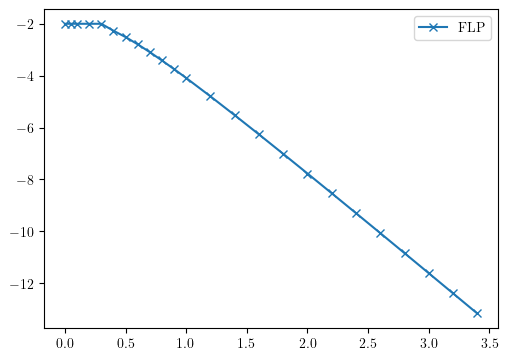

In [80]:
delta_t_index = 0
print('tx =', tx_arr[delta_t_index], ' ty =', ty_arr[delta_t_index])

plt.plot(V_0_arr, e_arr[delta_t_index].real, marker='x', label=r'FLP')

plt.legend()

# Phase Diagram

## In $\Delta_t - V_0$ plane

### Interpolation

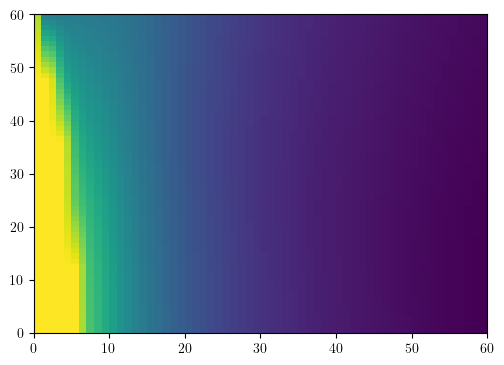

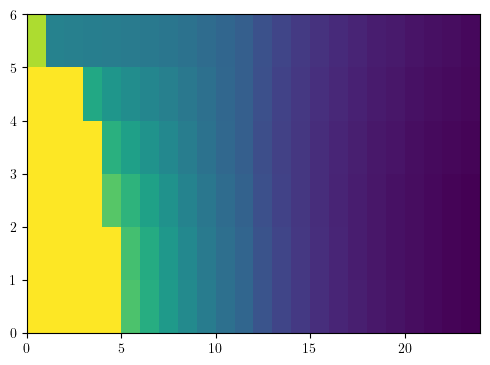

In [81]:
def interpolate_data_loc(x,y,x_points,y_points,data):    
    f = scipy.interpolate.RegularGridInterpolator((x.real, y.real), data.real, bounds_error=False, fill_value=None)
    
    Xnew = np.linspace(x[0].real, x[-1].real, x_points)
    Ynew = np.linspace(y[0].real, y[-1].real, y_points)
    Xnew, Ynew = np.meshgrid(Xnew, Ynew, indexing='ij')

    data_new = f((Xnew,Ynew), method='slinear')
    return Xnew, Ynew, data_new

def create_interp_array_loc(x,y,x_points,y_points,arr):
    arr_interp = np.zeros((4,x_points,y_points))
    
    X_intp, Y_intp, arr_interp = interpolate_data_loc(x,y,x_points,y_points,arr.real)
    
    return X_intp, Y_intp, arr_interp
    
delta_t = tx_arr-ty_arr
x_points = 60
y_points = 60

X_intp, Y_intp, e_arr_interp = create_interp_array_loc(delta_t,V_0_arr,x_points,y_points,e_arr)
X_intp, Y_intp, Tx_arr_interp = create_interp_array_loc(delta_t,V_0_arr,x_points,y_points,Tx_arr)
X_intp, Y_intp, Ty_arr_interp = create_interp_array_loc(delta_t,V_0_arr,x_points,y_points,Ty_arr)

plt.pcolormesh(np.abs(Tx_arr_interp+Ty_arr_interp)); plt.show()
plt.pcolormesh(np.abs(Tx_arr+Ty_arr))

In [82]:
def plot_delta_t_phase_diagram(x,y,m_size,Tx,Ty,file_save):
    A = 6
    plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
    plt.rc('text', usetex=True)
    plt.rc('font', family='serif')
    font_size = 20 # 14

    fig, ax = plt.subplots(figsize=[53 * .5**(.5 * A), 33.11 * .5**(.5 * A)])

    y1 = -y.copy()

    x_points = len(x)
    y_points = len(y) 
    
    img1 = np.ones((y_points,x_points,3)) # image for upper half
    img2 = np.ones((y_points,x_points,3)) # image for lower half
    
    '''
    A very simple colormap:
    #  mapping parameter 1 to the red channel and 
    #          parameter 2 to the blue channel
    '''
    green_frac = 0.83
    cmap = lambda p1,p2 : ((1-np.abs(p1/2))**(1/3), green_frac, (1-np.abs(p2/2))**(1/3))
    
    p1 = Tx
    p2 = Ty
    for j in range(len(y)):
        for i in range(len(x)):
            plt.plot(x[i], y[j], marker="s", markersize=m_size, color=cmap(p1[j,i],p2[j,i]))
            plt.plot(x[i], y1[j], marker="s", markersize=m_size, color=cmap(p2[j,i],p1[j,i]))

            img1[j,i] = cmap(p1[j,i],p2[j,i])
            img2[j,i] = cmap(p2[j,i],p1[j,i])

    ax.annotate(r'FLP', xy=(0.2, -0.1), xytext=(0.2, -0.051), fontsize=20, color='black')
    ax.annotate(r'FDW$_x$', xy=(0.2, 0), xytext=(0.6, 0.6), fontsize=20, color='black')
    ax.annotate(r'FDW$_y$', xy=(0.2, 0), xytext=(0.6, -0.7), fontsize=20, color='black')
    ax.annotate(r'FSP', xy=(0.2, -0.1), xytext=(1.3, -0.051), fontsize=20, color='black')
    plt.plot(np.array([0,0.612]), np.array([1,0]), linestyle='solid', color='grey', linewidth=1, alpha=0.8)
    plt.plot(np.array([0,0.612]), np.array([-1,0]), linestyle='solid', color='grey', linewidth=1, alpha=0.8)
    plt.plot(np.array([0.8375,1.7]), np.array([0,1]), linestyle='solid', color='grey', linewidth=1, alpha=0.8)
    plt.plot(np.array([0.8375,1.7]), np.array([0,-1]), linestyle='solid', color='grey', linewidth=1, alpha=0.8)
    plt.plot(np.array([0.6,0.8]), np.array([0,0]), linestyle='solid', color='grey', linewidth=1, alpha=0.8)


    plt.xlim(0,2)
    plt.ylim(-1,1)

    plt.xlabel(r'$V_0/t$', fontsize=font_size)
    plt.ylabel(r'$\Delta_t$', fontsize=font_size)

    plt.xticks([0,0.5,1,1.5,1.75],[r'0.0',r'0.5',r'1.0',r'1.5',r''], fontsize=font_size)
    plt.yticks([-1,-0.5,0,0.5,1],[r'-1.0',r'-0.5',r'0.0',r'0.5',r'1.0'], fontsize=font_size)

    plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7) # 4
    plt.tick_params(axis='y', direction='in', length=6, right=True)

    plt.tick_params(which='minor', axis='y', direction='in', right=True)

    plt.subplots_adjust(left=0.1, right=0.65, top=0.85)
    cax = fig.add_axes([0.54,0.7,0.1,0.1]) #([0.54,0.7,0.1,0.1]) #fig.add_axes([0.72,0.55,0.3,0.3])
    cp1 = np.linspace(0, 1, 100)
    cp2 = np.linspace(0, 1, 100)
    Cp1, Cp2 = np.meshgrid(cp1,cp2)
    C0 = green_frac*np.ones_like(Cp2)
    # make RGB image, p1 to red channel, p2 to blue channel
    Legend = np.dstack(((1-Cp1)**(1/3),C0,(1-Cp2)**(1/3)))

    # parameters range between 0 and 1
    cax.imshow(Legend, origin="lower", extent=[0,2,0,2])
    cax.set_xticks([0,1,2], [r'0',r'1',r'2'], fontsize=0.75*font_size)
    cax.set_yticks([0,1,2], [r'0',r'1',r'2'], fontsize=0.75*font_size)
    cax.set_xlabel(r'$\mathcal{T}_x$', fontsize=0.75*font_size)
    cax.set_ylabel(r'$\mathcal{T}_y$', fontsize=0.75*font_size)

    plt.show()
    plt.savefig(file_save, bbox_inches='tight', dpi=500, transparent=True)
    return img1, img2

'''
This plotting routine just fills white gaps in the plot - can be useful for irregular grids!
'''
def plot_delta_t_phase_diagram_img(x,y,img1,img2,file_save):
    A = 6
    plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
    plt.rc('text', usetex=True)
    plt.rc('font', family='serif')
    font_size = 20 # 14

    fig, ax = plt.subplots(figsize=[53 * .5**(.5 * A), 33.11 * .5**(.5 * A)])

    Xgrid, Ygrid = np.meshgrid(y, x, indexing='ij')

    plt.pcolormesh(Ygrid, Xgrid, img1, antialiased=True, rasterized=True)
    plt.pcolormesh(Ygrid, -Xgrid, img2, antialiased=True, rasterized=True)

    ax.annotate(r'FLP', xy=(0.2, -0.1), xytext=(0.2, -0.051), fontsize=20, color='black')
    ax.annotate(r'FDW$_x$', xy=(0.2, 0), xytext=(0.6, 0.6), fontsize=20, color='black')
    ax.annotate(r'FDW$_y$', xy=(0.2, 0), xytext=(0.6, -0.7), fontsize=20, color='black')
    ax.annotate(r'FSP', xy=(0.2, -0.1), xytext=(1.3, -0.051), fontsize=20, color='black')

    plt.xlim(0,2)
    plt.ylim(-1,1)

    plt.xlabel(r'$V_0/t$', fontsize=font_size)
    plt.ylabel(r'$\Delta_t$', fontsize=font_size)

    plt.xticks([0,0.5,1,1.5,1.75],[r'0.0',r'0.5',r'1.0',r'1.5',r''], fontsize=font_size)
    plt.yticks([-1,-0.5,0,0.5,1],[r'-1.0',r'-0.5',r'0.0',r'0.5',r'1.0'], fontsize=font_size)

    plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7) # 4
    plt.tick_params(axis='y', direction='in', length=6, right=True)

    plt.tick_params(which='minor', axis='y', direction='in', right=True)

    plt.subplots_adjust(left=0.1, right=0.65, top=0.85)
    cax = fig.add_axes([0.54,0.7,0.1,0.1]) #([0.54,0.7,0.1,0.1]) #fig.add_axes([0.72,0.55,0.3,0.3])
    cp1 = np.linspace(0, 1, 100)
    cp2 = np.linspace(0, 1, 100)
    Cp1, Cp2 = np.meshgrid(cp1,cp2)
    C0 = green_frac*np.ones_like(Cp2)
    # make RGB image, p1 to red channel, p2 to blue channel
    Legend = np.dstack(((1-Cp1)**(1/3),C0,(1-Cp2)**(1/3)))

    # parameters range between 0 and 1
    cax.imshow(Legend, origin="lower", extent=[0,2,0,2])
    cax.set_xticks([0,1,2], [r'0',r'1',r'2'], fontsize=0.75*font_size)
    cax.set_yticks([0,1,2], [r'0',r'1',r'2'], fontsize=0.75*font_size)
    cax.set_xlabel(r'$\mathcal{T}_x$', fontsize=0.75*font_size)
    cax.set_ylabel(r'$\mathcal{T}_y$', fontsize=0.75*font_size)

    plt.savefig(file_save, bbox_inches='tight', dpi=500, transparent=True)

### Plotting the Energy

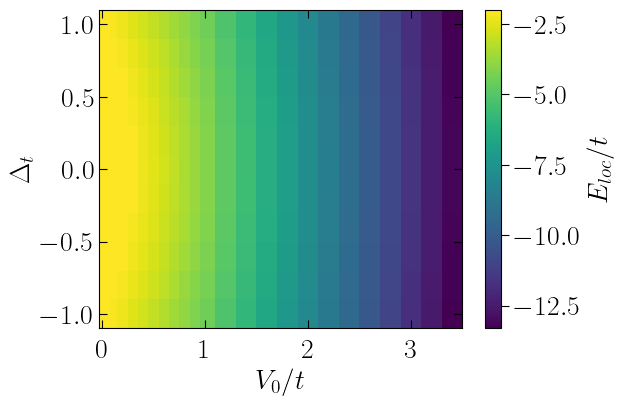

In [83]:
'''Raw Data without Interpolation'''
X, Y = np.meshgrid(V_0_arr, tx_arr-ty_arr)

pc = plt.pcolormesh(X,Y,e_arr.real, antialiased=False) # cmap='gnuplot',
pc = plt.pcolormesh(X,-Y,e_arr.real, antialiased=False) # cmap='gnuplot',
cbar = fig.colorbar(pc)
cbar.ax.tick_params(length=6, labelsize=font_size)
cbar.set_label(label=r'$E_{loc}/t$', size=20)

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$\Delta_t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size)
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

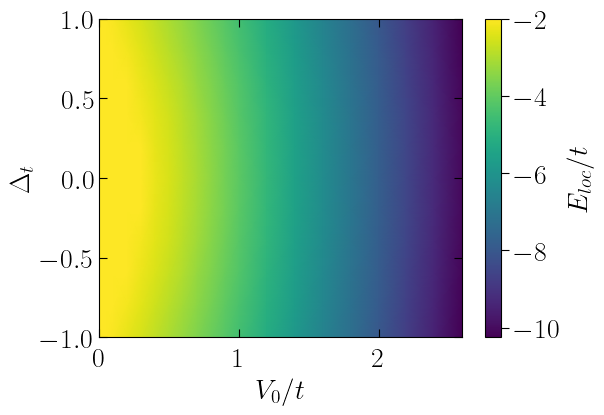

In [25]:
'''With Interpolation'''
X, Y = np.meshgrid(V_0_arr, tx_arr-ty_arr)

pc = plt.pcolormesh(X,Y,e_arr.real, antialiased=False, shading='gouraud') # cmap='gnuplot',
pc = plt.pcolormesh(X,-Y,e_arr.real, antialiased=False, shading='gouraud') # cmap='gnuplot',
cbar = fig.colorbar(pc)
cbar.ax.tick_params(length=6, labelsize=font_size)
cbar.set_label(label=r'$E_{loc}/t$', size=20)

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$\Delta_t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size)
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

plt.savefig('img_results/energy_localized_interp.svg', bbox_inches='tight', dpi=500, transparent=True)

### Plotting the Order Parameter

/tmp/ipykernel_3655547/1941137770.py:24: RuntimeWarning: invalid value encountered in scalar power
  cmap = lambda p1,p2 : ((1-np.abs(p1/2))**(1/3), green_frac, (1-np.abs(p2/2))**(1/3))


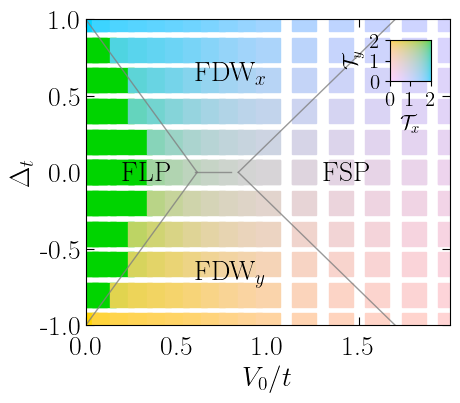

/tmp/ipykernel_3655547/1941137770.py:24: RuntimeWarning: invalid value encountered in scalar power
  cmap = lambda p1,p2 : ((1-np.abs(p1/2))**(1/3), green_frac, (1-np.abs(p2/2))**(1/3))


<Figure size 585.25x413.875 with 0 Axes>

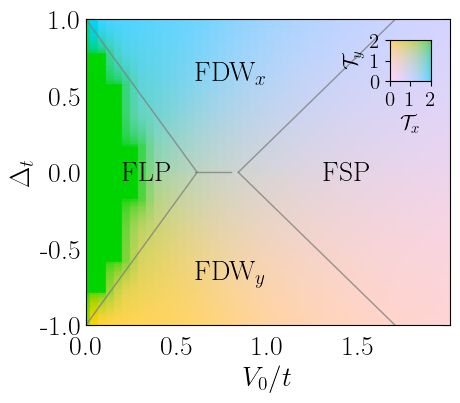

<Figure size 585.25x413.875 with 0 Axes>

In [78]:
delta_t = tx_arr-ty_arr
img1, img2 = plot_delta_t_phase_diagram(x=V_0_arr,y=delta_t,m_size=17,Tx=Tx_arr,Ty=Ty_arr,file_save='img_results/pd_loc_delta_t_B_1e-2t.png')

x_intp = np.linspace(V_0_arr[0], V_0_arr[-1], x_points)
y_intp = np.linspace(delta_t[0], delta_t[-1], y_points)

img1_intp, img2_intp = plot_delta_t_phase_diagram(x=x_intp,y=y_intp,m_size=6,Tx=Tx_arr_interp,Ty=Ty_arr_interp,file_save='img_results/pd_intp_loc_V0_delta_t_B_1e-2t.svg')

### Detail of Order Parameter

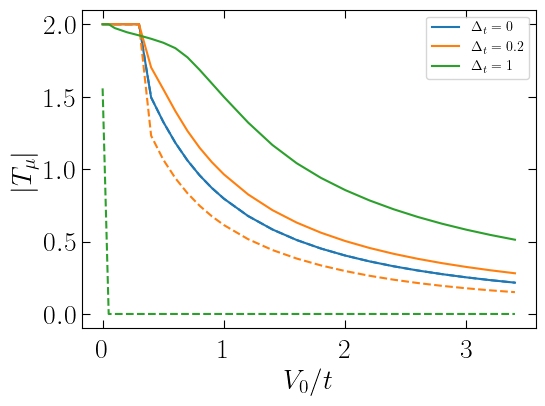

In [84]:
i = 0
plt.plot(V_0_arr, Tx_arr[i].real, linestyle='solid', color='tab:blue', label=r'$\Delta_t = 0$')
plt.plot(V_0_arr, Ty_arr[i].real, linestyle='dashed', color='tab:blue')

i = 1
plt.plot(V_0_arr, Tx_arr[i].real, linestyle='solid', color='tab:orange', label=r'$\Delta_t = 0.2$')
plt.plot(V_0_arr, Ty_arr[i].real, linestyle='dashed', color='tab:orange')

i = 5
plt.plot(V_0_arr, Tx_arr[i].real, linestyle='solid', color='tab:green', label=r'$\Delta_t = 1$')
plt.plot(V_0_arr, Ty_arr[i].real, linestyle='dashed', color='tab:green')

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$|T_{\mu}|$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size) # 4
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

plt.legend()
plt.savefig('img_results/pd_loc_order_parameter.svg', bbox_inches='tight', dpi=500, transparent=True)

# Comparison vGH - Localized

## Energy Comparison

In [86]:
'''
vGH: Get State Properties for a phase diagram scan in the delta_t-V_0 plane
'''
V_0_arr_vgh = np.array([0.0,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.2,1.4,1.6,1.8,2.0,2.2,2.4,2.6,2.8,3.0,3.2,3.4])

Mx_vgh = 10
My_vgh = 10
tx_arr_vgh = np.array([0.5,0.6,0.7,0.8,0.9,1.0])
ty_arr_vgh = np.array([0.5,0.4,0.3,0.2,0.1,0.0])
B_vgh = 1e-2

qx_vgh=0.0
qy_vgh=0.0

dir='data_vgh/'
e_arr_vgh, e_T_arr_vgh, e_B_arr_vgh, e_V_arr_vgh, Tx_arr_vgh, Ty_arr_vgh = get_state_e_vgh_data(dir=dir,Mx=Mx_vgh,My=My_vgh,tx_arr=tx_arr_vgh,ty_arr=ty_arr_vgh,qx=qx_vgh,qy=qx_vgh,B=B_vgh,V_0_arr=V_0_arr_vgh)
e_gs_vgh, Tx_gs_vgh, Ty_gs_vgh = get_gs_phase_diagram(e_arr_vgh,Tx_arr_vgh,Ty_arr_vgh)

e_diff = e_gs_vgh - e_arr

print('Shape E_gs_loc, Shape E_gs_vgh =', e_arr.shape, ',', e_gs_vgh.shape)

Shape E_gs_loc, Shape E_gs_vgh = (6, 24) , (6, 24)


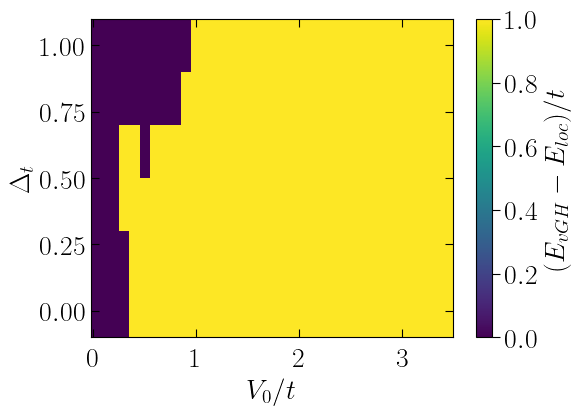

In [87]:
e_diff_heav = np.zeros(e_diff.shape)
for i in range(e_diff.shape[0]):
    for j in range(e_diff.shape[1]):
        if e_diff.real[i,j] > 0:
            e_diff_heav[i,j] = 1
        else:
            e_diff_heav[i,j] = 0

X, Y = np.meshgrid(V_0_arr, tx_arr-ty_arr)

pc = plt.pcolormesh(X,Y,e_diff_heav.real, antialiased=False) #, shading='gouraud') # cmap='gnuplot',
#pc = plt.pcolormesh(X,-Y,e_diff.real, antialiased=False, shading='gouraud') # cmap='gnuplot',
cbar = fig.colorbar(pc)
cbar.ax.tick_params(length=6, labelsize=font_size)
cbar.set_label(label=r'$(E_{vGH}-E_{loc})/t$', size=20)

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$\Delta_t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size)
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)
#plt.savefig('img_results/diff_vgh_loc_mesh.svg', bbox_inches='tight', dpi=500, transparent=True)

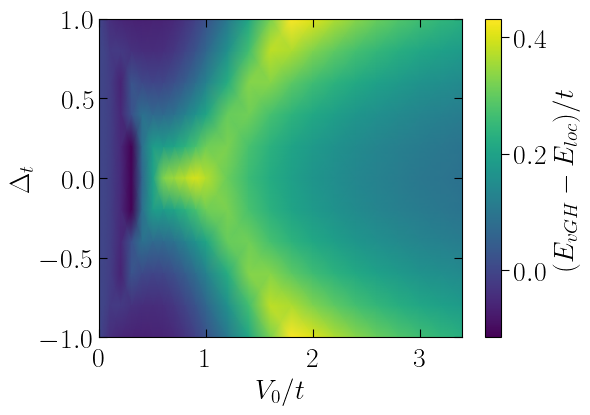

In [88]:
X, Y = np.meshgrid(V_0_arr, tx_arr-ty_arr)

pc = plt.pcolormesh(X,Y,e_diff.real, antialiased=False, shading='gouraud') # cmap='gnuplot',
pc = plt.pcolormesh(X,-Y,e_diff.real, antialiased=False, shading='gouraud') # cmap='gnuplot',
cbar = fig.colorbar(pc)
cbar.ax.tick_params(length=6, labelsize=font_size)
cbar.set_label(label=r'$(E_{vGH}-E_{loc})/t$', size=20)

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$\Delta_t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size)
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)
plt.savefig('img_results/diff_vgh_loc_mesh.svg', bbox_inches='tight', dpi=500, transparent=True)

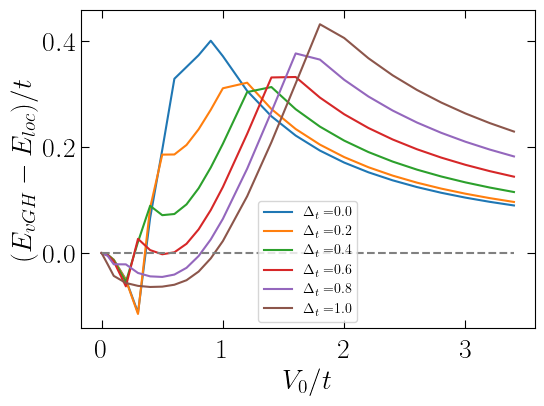

In [89]:
for i in range(e_diff.shape[0]):
    plt.plot(V_0_arr, e_diff[i].real, label=r'$\Delta_t = $'+str(round((tx_arr-ty_arr)[i],1)))

plt.hlines(y=0, xmin=V_0_arr[0], xmax=V_0_arr[-1], linestyle='dashed', color='grey')

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$(E_{vGH}-E_{loc})/t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size) # 4
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

plt.legend()
plt.savefig('img_results/diff_vgh_loc_lines.svg', bbox_inches='tight', dpi=500, transparent=True)

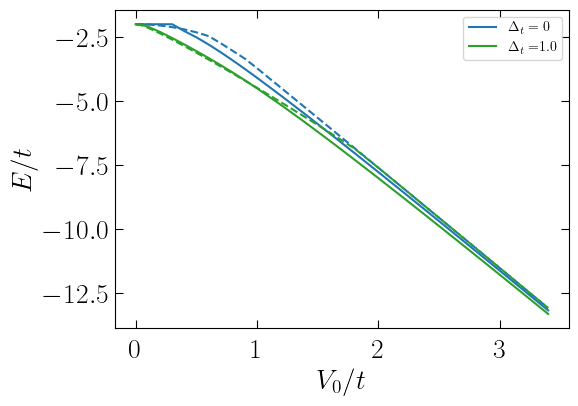

In [95]:
i = 0
plt.plot(V_0_arr, e_arr[i].real, linestyle='solid', color='tab:blue', label=r'$\Delta_t = 0$')
plt.plot(V_0_arr, e_gs_vgh[i].real, linestyle='dashed', color='tab:blue')

i = 5
plt.plot(V_0_arr, e_arr[i].real, linestyle='solid', color='tab:green', label=r'$\Delta_t = $'+str(round((tx_arr-ty_arr)[i],1)))
plt.plot(V_0_arr, e_gs_vgh[i].real, linestyle='dashed', color='tab:green')

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$E/t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size) # 4
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

plt.legend()
plt.savefig('img_results/comp_vgh_loc_energies.svg', bbox_inches='tight', dpi=500, transparent=True)

## Jahn-Teller Scan in Asymmetry Parameter

V0 =  0.9


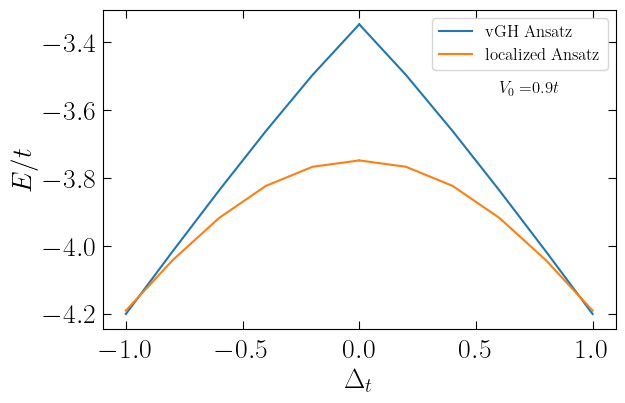

In [145]:
#e_gs_vgh - e_arr
delta_t_arr = tx_arr-ty_arr

A = 6
plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
font_size = 20 # 14

fig, ax = plt.subplots(figsize=[53 * .5**(.5 * A), 33.11 * .5**(.5 * A)])

i = 10
print("V0 = ", V_0_arr[i])
plt.plot(delta_t_arr, e_gs_vgh.T[i].real, color='tab:blue', label=r'vGH Ansatz')
plt.plot(-delta_t_arr, e_gs_vgh.T[i].real, color='tab:blue')

plt.plot(delta_t_arr, e_arr.T[i].real, color='tab:orange', label=r'localized Ansatz')
plt.plot(-delta_t_arr, e_arr.T[i].real, color='tab:orange')

ax.annotate(r'$V_0 =$'+str(V_0_arr[i])+r'$t$', xy=(0.6, -3.55), fontsize=0.6*font_size, color='black')
    
plt.xlabel(r'$\Delta_t$', fontsize=font_size)
plt.ylabel(r'$E/t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size) # 4
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

plt.legend(fontsize=0.6*font_size)
plt.savefig('img_results/pseudo_jahn_teller_vgh_loc.png', bbox_inches='tight', dpi=500, transparent=True)

TODO:

- scan for longer coupling strengths

# Wavefunction Characteristics

In [74]:
V_0_wfn = 0.4

Mx_wfn = 20
My_wfn = 20
tx_wfn = 0.5
ty_wfn = 0.5
B_wfn = 1e-2

dir = 'data_localized/'
x_angle, rot_wfn, ele_wfn, e_wfn, e_tun_wfn, e_B_wfn, e_V_wfn, Tx_wfn, Ty_wfn = get_wfn_loc_for_coupling(dir=dir,Mx=Mx_wfn,My=My_wfn,tx=tx_wfn,ty=ty_wfn,B=B_wfn,V_0=V_0_wfn)

print('E     =', e_wfn, '\nE_tun =', e_tun_wfn, '\nE_B   =', np.sum(e_B_wfn), '\nE_V   =', np.sum(e_V_wfn), '\nTx    =', Tx_wfn, '\nTy    =', Ty_wfn)

E     = (-2.2674771986539297-1.1308578889488715e-19j) 
E_tun = (-1.4946766041714679+0j) 
E_B   = (0.1191246150455994-1.1308578889488715e-19j) 
E_V   = -0.8919252095280613 
Tx    = (1.4946766041714685+0j) 
Ty    = (1.494676604171469+0j)


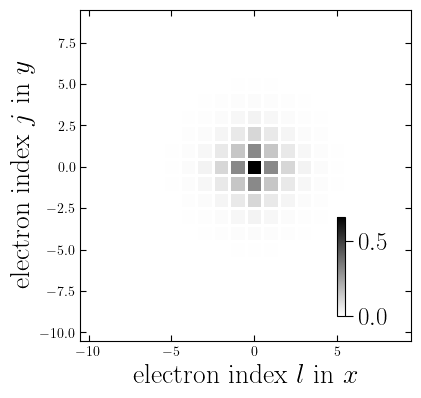

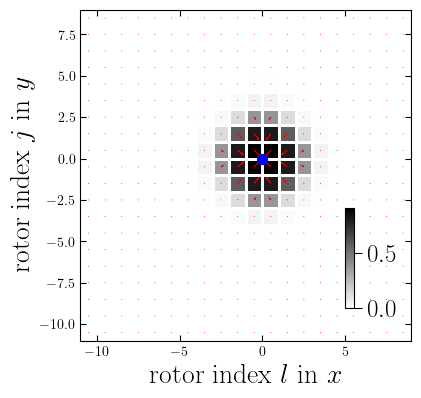

In [75]:
P_rotwfn, Px_rotwfn, Py_rotwfn = Px_Py_rotwfn(x_angle,Mx,My,rot_wfn.T)

'''
Electron Wavefunction
'''
x_arr = np.arange(-int(Px_plot.shape[0]/2),int(Px_plot.shape[0]/2),1)
X, Y = np.meshgrid(x_arr, x_arr) # np.meshgrid(np.arange(-4,5,1), np.arange(-4,5,1))

A = 6
plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
font_size = 20

fig, ax = plt.subplots(figsize=[4,4]) #[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)]) #, subplot_kw={"projection": "3d"})
ax.set_aspect("equal")

#plt.title(r'FO, $B=0.5\cdot 10^{-2}t$', fontsize=font_size)

'''Polarization Absolute Value'''
pc = plt.pcolormesh(X, Y, ele_wfn.real.T, cmap='binary', vmin=0.0, snap=True)#, facecolors='none') # norm=matplotlib.colors.LinNorm(vmin=0.1, vmax=1))

cax = ax.inset_axes([5, -9, 0.5, 6], transform=ax.transData)
cbar = fig.colorbar(pc, shrink=0.6, cax=cax, orientation='vertical') #, orientation="horizontal", pad=0.2)
cbar.ax.tick_params(length=6, labelsize=18)
#cbar.set_ticks(ticks=[0, 1, 2], labels=['0','1','2'])
#cbar.set_label(label=r'$\sigma^2_{\phi}/\sigma^2_0$', size=font_size)
cbar.solids.set_rasterized(True)
#pc.set_edgecolor('face')
pc.set_edgecolor('white')

plt.xlabel(r'electron index $l$ in $x$', fontsize=font_size)
plt.ylabel(r'electron index $j$ in $y$', fontsize=font_size)

#plt.xticks([-4.5,-3.5,-2.5,-1.5,-0.5,0.5,1.5,2.5,3.5,4.5],[r'-5',r'',r'-3',r'',r'-1',r'1',r'',r'3',r'',r'5'], fontsize=font_size)
#plt.yticks([-4.5,-3.5,-2.5,-1.5,-0.5,0.5,1.5,2.5,3.5,4.5],[r'-5',r'',r'-3',r'',r'-1',r'1',r'',r'3',r'',r'5'], fontsize=font_size)

#plt.xlim(-5,5)
#plt.ylim(-5,5)

plt.tick_params(axis='x', direction='in', length=4, top=True)
plt.tick_params(axis='y', direction='in', length=4, right=True)
plt.tick_params(which='minor', axis='x', direction='in', top=True)
plt.tick_params(which='minor', axis='y', direction='in', right=True)

ax.set_aspect(1)
fig.set_size_inches(4.3, 4.3, forward=True)

#plt.savefig('results/configurations/pol_size/p_vec_fo.svg')

'''
Rotor Wavefunction
'''

P_plot = P_rotwfn
Px_plot = Px_rotwfn
Py_plot = Py_rotwfn

x_arr = np.arange(-int(Px_plot.shape[0]/2),int(Px_plot.shape[0]/2),1)-0.5
X, Y = np.meshgrid(x_arr, x_arr) # np.meshgrid(np.arange(-4,5,1), np.arange(-4,5,1))

A = 6
plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
font_size = 20

fig, ax = plt.subplots(figsize=[4,4]) #[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)]) #, subplot_kw={"projection": "3d"})
ax.set_aspect("equal")

#plt.title(r'FO, $B=0.5\cdot 10^{-2}t$', fontsize=font_size)

'''Polarization Absolute Value'''
pc = plt.pcolormesh(X, Y, P_plot.real, cmap='binary', vmin=0.0, snap=True)#, facecolors='none') # norm=matplotlib.colors.LinNorm(vmin=0.1, vmax=1))

cax = ax.inset_axes([5, -9, 0.5, 6], transform=ax.transData)
cbar = fig.colorbar(pc, shrink=0.6, cax=cax, orientation='vertical') #, orientation="horizontal", pad=0.2)
cbar.ax.tick_params(length=6, labelsize=18)
#cbar.set_ticks(ticks=[0, 1, 2], labels=['0','1','2'])
#cbar.set_label(label=r'$\sigma^2_{\phi}/\sigma^2_0$', size=font_size)
cbar.solids.set_rasterized(True)
#pc.set_edgecolor('face')
pc.set_edgecolor('white')

'''Polarization Vector Plot'''
q = plt.quiver(X, Y, -Py_plot, -Px_plot, color='red', scale=30, headlength=3, headwidth=2)
#ax.invert_yaxis()

ax.scatter(-0, 0., marker='o', s=50, color='blue', alpha=1, zorder=2)
#ax.annotate(r'(c) $V_0/t=0.5$, FLP', xy=(0.2, -0.1), xytext=(-4.4, 3.8), fontsize=20, color='black')

plt.xlabel(r'rotor index $l$ in $x$', fontsize=font_size)
plt.ylabel(r'rotor index $j$ in $y$', fontsize=font_size)

#plt.xticks([-4.5,-3.5,-2.5,-1.5,-0.5,0.5,1.5,2.5,3.5,4.5],[r'-5',r'',r'-3',r'',r'-1',r'1',r'',r'3',r'',r'5'], fontsize=font_size)
#plt.yticks([-4.5,-3.5,-2.5,-1.5,-0.5,0.5,1.5,2.5,3.5,4.5],[r'-5',r'',r'-3',r'',r'-1',r'1',r'',r'3',r'',r'5'], fontsize=font_size)

#plt.xlim(-5,5)
#plt.ylim(-5,5)

plt.tick_params(axis='x', direction='in', length=4, top=True)
plt.tick_params(axis='y', direction='in', length=4, right=True)
plt.tick_params(which='minor', axis='x', direction='in', top=True)
plt.tick_params(which='minor', axis='y', direction='in', right=True)

ax.set_aspect(1)
fig.set_size_inches(4.3, 4.3, forward=True)

#plt.savefig('results/configurations/pol_size/p_vec_fo.svg')

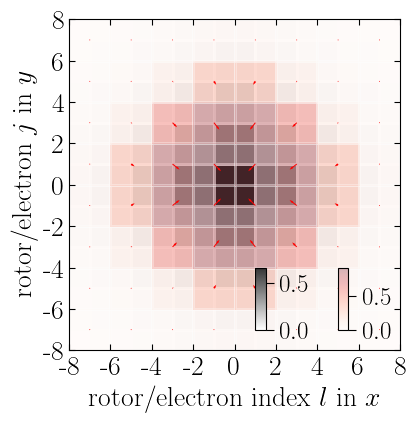

In [76]:
'''
Rotor Wavefunction
'''

P_plot = P_rotwfn
Px_plot = Px_rotwfn
Py_plot = Py_rotwfn

x_arr_ele = np.arange(-int(Px_plot.shape[0]),int(Px_plot.shape[0]),2)
X_ele, Y_ele = np.meshgrid(x_arr_ele, x_arr_ele) # np.meshgrid(np.arange(-4,5,1), np.arange(-4,5,1))

x_arr_rot = np.arange(-int(Px_plot.shape[0]),int(Px_plot.shape[0]),2)-0.5
X_rot, Y_rot = np.meshgrid(x_arr_rot, x_arr_rot) # np.meshgrid(np.arange(-4,5,1), np.arange(-4,5,1))

A = 6
plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
font_size = 20

fig, ax = plt.subplots(figsize=[4,4]) #[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)]) #, subplot_kw={"projection": "3d"})
ax.set_aspect("equal")

#plt.title(r'FO, $B=0.5\cdot 10^{-2}t$', fontsize=font_size)

'''Polarization Absolute Value'''
pc1 = plt.pcolormesh(X_ele, Y_ele, ele_wfn.real.T, cmap='binary', vmin=0.0, snap=True, alpha=0.8)#, facecolors='none') # norm=matplotlib.colors.LinNorm(vmin=0.1, vmax=1))
pc2 = plt.pcolormesh(X_rot-0.5, Y_rot-0.5, P_plot.real, cmap='Reds', vmin=0.0, snap=True, alpha=0.3)#, facecolors='none') # norm=matplotlib.colors.LinNorm(vmin=0.1, vmax=1))

cax = ax.inset_axes([1, -7, 0.5, 3], transform=ax.transData)
cbar = fig.colorbar(pc1, shrink=0.6, cax=cax, orientation='vertical') #, orientation="horizontal", pad=0.2)
cbar.ax.tick_params(length=6, labelsize=18)
#cbar.set_ticks(ticks=[0, 1, 2], labels=['0','1','2'])
#cbar.set_label(label=r'$\sigma^2_{\phi}/\sigma^2_0$', size=font_size)
cbar.solids.set_rasterized(True)
#pc.set_edgecolor('face')
pc1.set_edgecolor('white')

cax = ax.inset_axes([5, -7, 0.5, 3], transform=ax.transData)
cbar = fig.colorbar(pc2, shrink=0.6, cax=cax, orientation='vertical') #, orientation="horizontal", pad=0.2)
cbar.ax.tick_params(length=6, labelsize=18)
#cbar.set_ticks(ticks=[0, 1, 2], labels=['0','1','2'])
#cbar.set_label(label=r'$\sigma^2_{\phi}/\sigma^2_0$', size=font_size)
cbar.solids.set_rasterized(True)
#pc.set_edgecolor('face')
pc2.set_edgecolor('white')

'''Polarization Vector Plot'''
q = plt.quiver(X_rot-0.5, Y_rot-0.5, -Py_plot, -Px_plot, color='red', scale=30, headlength=3, headwidth=2)
#ax.invert_yaxis()

#ax.scatter(-0.5, -0.5, marker='o', s=50, color='blue', alpha=1, zorder=2)
#ax.annotate(r'(c) $V_0/t=0.5$, FLP', xy=(0.2, -0.1), xytext=(-4.4, 3.8), fontsize=20, color='black')

plt.xlabel(r'rotor/electron index $l$ in $x$', fontsize=font_size)
plt.ylabel(r'rotor/electron $j$ in $y$', fontsize=font_size)

plt.xticks([-8,-6,-4,-2,0,2,4,6,8],[r'-8',r'-6',r'-4',r'-2',r'0',r'2',r'4',r'6',r'8'], fontsize=font_size)
plt.yticks([-8,-6,-4,-2,0,2,4,6,8],[r'-8',r'-6',r'-4',r'-2',r'0',r'2',r'4',r'6',r'8'], fontsize=font_size)

#plt.xticks([-4.5,-3.5,-2.5,-1.5,-0.5,0.5,1.5,2.5,3.5,4.5],[r'-5',r'',r'-3',r'',r'-1',r'1',r'',r'3',r'',r'5'], fontsize=font_size)
#plt.yticks([-4.5,-3.5,-2.5,-1.5,-0.5,0.5,1.5,2.5,3.5,4.5],[r'-5',r'',r'-3',r'',r'-1',r'1',r'',r'3',r'',r'5'], fontsize=font_size)

plt.xlim(-8,8)
plt.ylim(-8,8)

plt.tick_params(axis='x', direction='in', length=4, top=True)
plt.tick_params(axis='y', direction='in', length=4, right=True)
plt.tick_params(which='minor', axis='x', direction='in', top=True)
plt.tick_params(which='minor', axis='y', direction='in', right=True)

ax.set_aspect(1)
fig.set_size_inches(4.3, 4.3, forward=True)

plt.savefig('img_results/loc_wavefunc_delta_t_0.8_V0_0.4.svg')

# Finite Size Convergence

In [57]:
'''
Size 1: Get State Properties for a phase diagram scan in the delta_t-V_0 plane
'''
V_0_arr_s1 = np.array([0.0,0.2,0.4,0.6,0.8,1.0,1.2,1.4,1.6,1.8,2.0])

Mx_s1 = 20
My_s1 = 20
tx_arr_s1 = np.array([0.5,0.6,0.7,0.8,0.9,1.0])
ty_arr_s1 = np.array([0.5,0.4,0.3,0.2,0.1,0.0])
B_s1 = 1e-2

qx_s1=0.0
qy_s1=0.0

dir='data_localized/'
e_arr_s1, e_T_arr_s1, e_B_arr_s1, e_V_arr_s1, Tx_arr_s1, Ty_arr_s1 = get_state_e_loc_data(dir=dir,Mx=Mx_s1,My=My_s1,tx_arr=tx_arr_s1,ty_arr=ty_arr_s1,B=B_s1,V_0_arr=V_0_arr_s1)

In [58]:
'''
Size 2: Get State Properties for a phase diagram scan in the delta_t-V_0 plane
'''
V_0_arr_s2 = np.array([0.0,0.2,0.4,0.6,0.8,1.0,1.2,1.4,1.6,1.8,2.0])

Mx_s2 = 40
My_s2 = 40
tx_arr_s2 = np.array([0.5,0.6,0.7,0.8,0.9,1.0])
ty_arr_s2 = np.array([0.5,0.4,0.3,0.2,0.1,0.0])
B_s2 = 1e-2

qx_s2=0.0
qy_s2=0.0

dir='data_localized/'
e_arr_s2, e_T_arr_s2, e_B_arr_s2, e_V_arr_s2, Tx_arr_s2, Ty_arr_s2 = get_state_e_loc_data(dir=dir,Mx=Mx_s2,My=My_s2,tx_arr=tx_arr_s2,ty_arr=ty_arr_s2,B=B_s2,V_0_arr=V_0_arr_s2)

In [59]:
diff_e_s1_s2 = e_arr_s2 - e_arr_s1

print('delta E max =', np.max(diff_e_s1_s2))
print('delta E min =', np.min(diff_e_s1_s2))

delta E max = (7.223149055013423e-05-4.988428871156299e-20j)
delta E min = (-8.683187502356304e-11-1.7931080296624327e-18j)


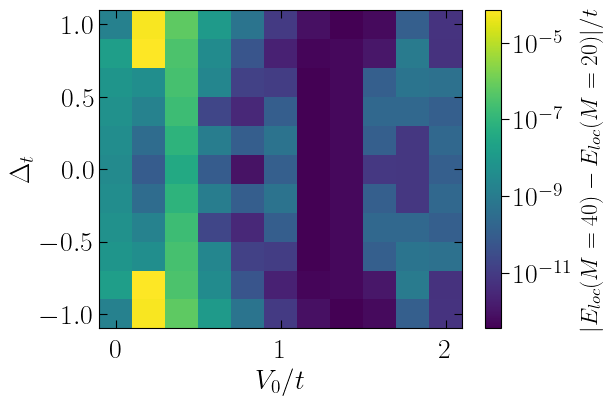

In [60]:
import matplotlib.colors as colors

X, Y = np.meshgrid(V_0_arr_s1, tx_arr_s1-ty_arr_s1)

Z = np.abs(diff_e_s1_s2.real)

pc = plt.pcolormesh(X,Y,Z, antialiased=False, norm=colors.LogNorm(vmin=Z.min(), vmax=Z.max())) 
pc = plt.pcolormesh(X,-Y,Z, antialiased=False, norm=colors.LogNorm(vmin=Z.min(), vmax=Z.max()))
cbar = fig.colorbar(pc)
cbar.ax.tick_params(length=6, labelsize=font_size)
cbar.set_label(label=r'$|E_{loc}(M=40)-E_{loc}(M=20)|/t$', size=17)

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$\Delta_t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size)
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)